In [1]:
# salloc -t 60 -p short -J Interase_DIL --ntasks=1 --cpus-per-task=4 --mem=64G srun --pty bash

#module purge
#module load cuda/12.0
#module load anaconda/2024.10-1
#source "$(conda info --base)/etc/profile.d/conda.sh"
#conda activate torch_gpu

In [2]:
# python stage4_eval.py --list sbc_lists/pathA.list --out eval_sbc_out/pathA --dlogp 10 --n-corner 4 --filtered-only
# python stage4_eval.py --list sbc_lists/pathB_replicate.list --out eval_sbc_out/pathB_replicate --dlogp 10 --n-corner 4 --filtered-only
# python stage4_eval.py --list sbc_lists/baseline.list --out eval_sbc_out/reference --dlogp 10 --n-corner 4 --filtered-only

## Setup

In [3]:
import os, subprocess, sys
from pathlib import Path
import numpy as np, yaml
from IPython.display import Image, display

# notebooks/ -> repo root, so tools/ and configs/ resolve
REPO = Path.cwd().resolve()
if REPO.name == "notebook":
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))
from sbi.seeding import resolve_arm_name      # torch-free, safe on a login node

FIGS = REPO / "notebook" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)

repo: /obs/ddehiwalage-don/21cm/sbi_project_FIN


In [4]:
def sh(cmd):
    print("$", cmd, flush=True)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout.strip(): print(r.stdout.strip()[-2500:])
    if r.returncode:     print("[FAILED]", r.stderr.strip()[-2500:])
    return r.returncode == 0

def show(p, width=1100):
    p = str(p)
    if p.endswith(".pdf"):                     # rasterise for inline display
        prev = p[:-4] + "_preview"
        if os.system(f'pdftoppm -png -r 150 -singlefile "{p}" "{prev}" 2>/dev/null') == 0:
            p = prev + ".png"
    display(Image(p, width=width)) if os.path.exists(p) else print("missing:", p)

def arm(cfg_path):
    """Everything the plotters need, derived from one config.

    resolve_arm_name appends _s<init_seed> when compressor.tag_arm_with_seed is
    on, so using it (rather than raw arm_name) keeps the notebook pointing at
    the same tree stages 1-3 wrote, in both layouts.
    """
    c  = yaml.safe_load(open(cfg_path))
    cc = c.get("compressor", {}) or {}
    nc = c.get("nle", {}) or {}
    root = Path(c["scratch_root"]) / resolve_arm_name(c)
    # scope resolution, mirroring stage2_nle.py exactly:
    #   t_scaling  >  standardize  >  default "standard"
    mode = str(nc.get("t_scaling") or
               ("standard" if nc.get("standardize", True) else "raw")).lower()
    return dict(cfg=cfg_path, type=c.get("arm_type", "cnn"), root=root,
                nle=root / "nle", summ=root / "summaries", chains=root / "chains",
                scope="standard_t" if mode == "standard" else "raw_t",
                t_scaling=mode,
                dequant=cc.get("dequant", {}) or {},
                sigma_floor=float(cc.get("sigma_floor", 1e-2)),
                epochs=int(cc.get("epochs", 0)))

In [5]:
!python check_status.py configs/vmim_/arm_cnn_vmim_n1_jit_0.1.yaml --auto-seeds --families nsf



cnn_vmim_up/jitter/seed_n1_s43   [cnn, scope=standard_t]
  stage1  DONE     9,120,000 rows x 4
  nsf/n42     stage2 DONE     15/15 chunks, best val -9.3450
              stage3 DONE     908 chains
  nsf/n43     stage2 DONE     15/15 chunks, best val -9.2429
              stage3 DONE     908 chains

cnn_vmim_up/jitter/seed_n1_s44   [cnn, scope=standard_t]
  stage1  DONE     9,120,000 rows x 4
  nsf/n42     stage2 DONE     15/15 chunks, best val -8.8636
              stage3 DONE     908 chains
  nsf/n43     stage2 DONE     15/15 chunks, best val -8.8471
              stage3 DONE     908 chains

cnn_vmim_up/jitter/seed_n1_s45   [cnn, scope=standard_t]
  stage1  DONE     9,120,000 rows x 4
  nsf/n42     stage2 DONE     15/15 chunks, best val -9.3184
              stage3 DONE     908 chains
  nsf/n43     stage2 DONE     15/15 chunks, best val -9.2221
              stage3 DONE     908 chains

6/6 cells complete -- ALL DONE


## Groups

Edit this cell only. `ONLY` restricts every section below to one group.

In [7]:
NAMES = ["Fx", "tau", "rHS", "Mmin"]     # theta order, NOT latent dims

GROUPS = {
    #"baseline": dict(
    #    families=["gmm"],
    #    arms={"pdf":    "configs/baseline_/baseline_pdf.yaml",
    #         "ps":     "configs/baseline_/baseline_ps.yaml",
    #          "pdf_ps": "configs/baseline_/baseline_pdf_ps.yaml"}),
    #"path A": dict(
    #    families=["gmm", "nsf"],
    #    arms={"pdf":    "configs/mlp_/arm_mlp_pdf.yaml",
    #          "ps":     "configs/mlp_/arm_mlp_ps.yaml",
    #          "pdf_ps": "configs/mlp_/arm_mlp_pdf_ps.yaml"}),
    "path B": dict(
        families=["nsf"],
        arms={#"vmim jitter (legacy)":    "configs/vmim_/legacy/arm_cnn_vmim_jitter_n1.yaml",
            
              "vmim jitter (0.1) n1": "configs/vmim_/arm_cnn_vmim_n1_jit_0.1.yaml",
              "vmim no jit n1": "configs/vmim_/arm_cnn_vmim_n1.yaml",
              "vmim no jit n2": "configs/vmim_/arm_cnn_vmim_n1.yaml",
     
              #"vmim jitter (new)":    "configs/vmim_/arm_cnn_vmim_jitter_n1.yaml",
              "mse":            "configs/mse_/arm_cnn_mse_n1.yaml"
              }),
              }

ONLY = None          # e.g. "path B" to restrict every section below

G = {g: {**v, "arms": {k: arm(p) for k, p in v["arms"].items()}}
     for g, v in GROUPS.items() if ONLY is None or g == ONLY}

for g, v in G.items():
    print(f"=== {g}  (families: {', '.join(v['families'])})")
    for k, a in v["arms"].items():
        print(f"  {k:<10} {a['type']:<4} {a['scope']:<11} nle={a['nle'].is_dir():<1} "
              f"summ={(a['summ']/'t.npy').exists():<1}  {a['root']}")

=== path B  (families: nsf)
  vmim jitter (0.1) n1 cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s43
  vmim no jit n1 cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n1_s43
  vmim no jit n2 cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n1_s43
  mse        cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_mse_up/seed_n1_s43


## 1. Progress

Read straight from the `.npy` logs, so this works mid-run.

`rf_r2_history.npy` is `[epoch, phase, aux_coef, R2 x P]`; the R2s are always the
last P columns and are indexed by **parameter**, not by latent dimension (the
trainer prints `t0..t3`, which is a misnomer). The **best** row is the one whose
checkpoint gets exported, so that is the line to watch.

In [8]:
for g, v in G.items():
    print(f"===== {g} =====")
    for k, a in v["arms"].items():
        if a["type"] == "raw":
            print(f"  {k:<10} raw arm -- no compressor to report")
            continue
        f = a["nle"] / "rf_r2_history.npy"
        if not f.exists():
            print(f"  {k:<10} no rf_r2_history yet"); continue
        h  = np.load(f)
        r2 = h[:, -len(NAMES):]
        b  = int(np.argmax(r2.mean(1)))
        print(f"  {k:<10} epoch {int(h[-1,0]):>3}/{a['epochs']}  "
              f"last R2 {np.round(r2[-1],3)} mean {r2[-1].mean():.3f}")
        print(f"  {'':<10} best @{int(h[b,0]):>3}   R2 {np.round(r2[b],3)} "
              f"mean {r2[b].mean():.3f}   <- exported checkpoint")
        l = a["nle"] / "loss_history.npy"
        if l.exists():
            ll = np.load(l)
            print(f"  {'':<10} vmim loss  train {ll[-1,1]:.4f}  val {ll[-1,2]:.4f}")
    print()

===== path B =====
  vmim jitter (0.1) n1 epoch 175/200  last R2 [0.965 0.913 0.78  0.937] mean 0.899
             best @100   R2 [0.971 0.934 0.803 0.953] mean 0.915   <- exported checkpoint
             vmim loss  train -9.7493  val -10.2787
  vmim no jit n1 epoch 175/200  last R2 [0.963 0.883 0.882 0.892] mean 0.905
             best @100   R2 [0.972 0.936 0.847 0.949] mean 0.926   <- exported checkpoint
             vmim loss  train -11.1757  val -11.8651
  vmim no jit n2 epoch 175/200  last R2 [0.963 0.883 0.882 0.892] mean 0.905
             best @100   R2 [0.972 0.936 0.847 0.949] mean 0.926   <- exported checkpoint
             vmim loss  train -11.1757  val -11.8651
  mse        epoch 200/200  last R2 [0.997 0.994 0.97  0.998] mean 0.990
             best @195   R2 [0.995 0.994 0.991 0.997] mean 0.994   <- exported checkpoint
             vmim loss  train 0.0015  val 0.0009



## 2. Compressor

One figure per group, arms overlaid -- only then are the VMIM losses on a
commensurable scale. Skipped for the baseline, which has no compressor.

The sigma panel carries three reference levels: the prior sigma
`1/sqrt(12) = 0.289` (the head learned nothing about that parameter), the
dequant floor `half/sqrt(3)` (it cannot resolve below the jitter width), and
`sigma_floor` (sitting on it means saturated / overconfident).

===== path B =====
$ python tools/plot_training_compressor.py "vmim jitter (0.1) n1"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s43/nle "vmim no jit n1"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n1_s43/nle "vmim no jit n2"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n1_s43/nle "mse"=/gscratch/ddehiwalage-don/sbi/cnn_mse_up/seed_n1_s43/nle --names Fx tau rHS Mmin --dequant 2:0.1 --sigma-floor 0.01 --out /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B.pdf --png
wrote /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B.pdf
wrote /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B.png

best RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  vmim jitter (0.1) n1    0.978     0.937     0.803     0.966
  vmim no jit n1          0.977     0.943     0.884     0.969
  vmim no jit n2          0.977     0.943     0.884     0.969
  mse                  

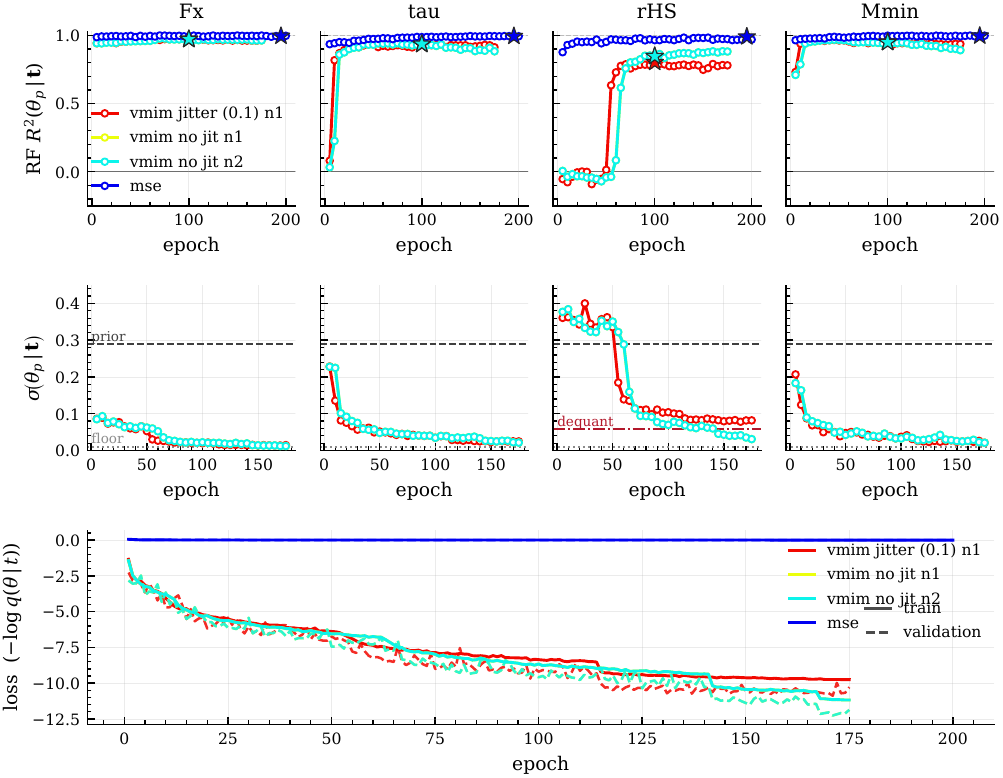

In [9]:
for g, v in G.items():
    arms = {k: a for k, a in v["arms"].items()
            if a["type"] != "raw" and (a["nle"] / "rf_r2_history.npy").exists()}
    if not arms:
        why = ("raw arm -- no compressor"
               if all(a["type"] == "raw" for a in v["arms"].values())
               else "stage 1 has not written rf_r2_history yet")
        print(f"[{g}] nothing to plot ({why})")
        continue
    deq = " ".join(f"{i}:{s['half']}" for a in arms.values()
                   for i, s in a["dequant"].items())
    args = " ".join(f'"{k}"={a["nle"]}' for k, a in arms.items())
    out  = FIGS / f"compressor_{g.replace(' ', '_')}.pdf"
    print(f"===== {g} =====")
    sh(f'python tools/plot_training_compressor.py {args} '
       f'--names {" ".join(NAMES)} '
       + (f'--dequant {deq} ' if deq else "")
       + f'--sigma-floor {list(arms.values())[0]["sigma_floor"]} --out {out} --png')
    show(out)

## 4. NLE

One row per config, one column per t-scaling scope found. Solid = train,
dashed = val, grey dotted = the phase-1 -> phase-2 learning-rate drop.

This is the only section the baseline participates in.

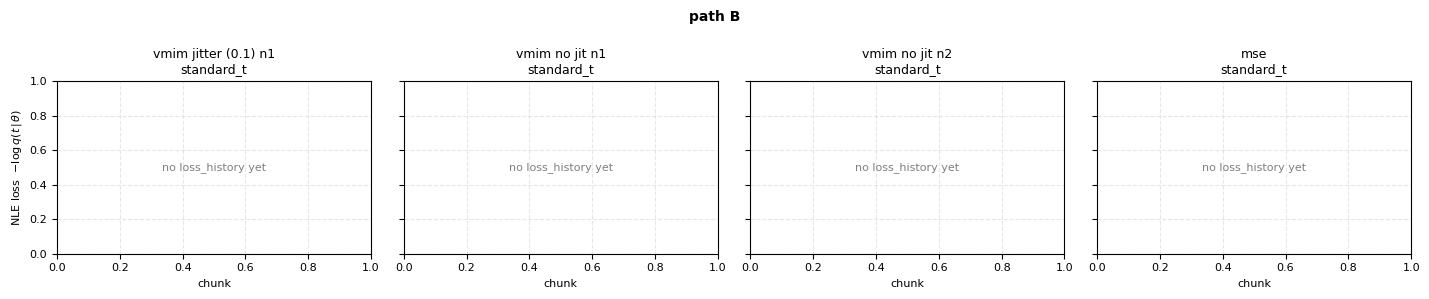

In [10]:
import matplotlib.pyplot as plt

def nle_loss(a, fam):
    """(chunks, train, val) from an arm's loss_history.npy, or None."""
    f = a["nle"] / a["scope"] / fam / "loss_history.npy"
    if not f.exists():
        return None
    h = np.load(f)
    if h.ndim == 1:
        h = h[None, :]
    return h[:, 0], h[:, 1], h[:, 2]

def nsplit_of(a):
    """nsplit drives the phase-1 -> phase-2 boundary (phase 1 = nsplit chunks)."""
    return int((yaml.safe_load(open(a["cfg"])).get("nle") or {}).get("nsplit", 10))

FAM_C = {"gmm": "tab:blue", "nsf": "tab:red", "maf": "tab:green", "made": "tab:orange"}

for g, v in G.items():
    arms = list(v["arms"].items())
    n = len(arms)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.0), sharey=True, squeeze=False)
    axes = axes[0]
    any_data = False

    for ax, (k, a) in zip(axes, arms):
        ns = nsplit_of(a)
        for fam in v["families"]:
            d = nle_loss(a, fam)
            if d is None:
                continue
            x, tr, va = d
            c = FAM_C.get(fam, "grey")
            ax.plot(x, tr, "-",  color=c, lw=1.6, label=f"{fam} train")
            ax.plot(x, va, "--", color=c, lw=1.2, alpha=0.75, label=f"{fam} val")
            b = int(np.argmin(va))
            ax.plot(x[b], va[b], "o", color=c, ms=5, mfc="white", mew=1.4)
            ax.annotate(f"{va[b]:.3f}", (x[b], va[b]), textcoords="offset points",
                        xytext=(3, -11), fontsize=7, color=c)
            any_data = True
            if len(x) > ns:          # only once the drop has actually happened
                ax.axvline(ns + 0.5, color="grey", ls=":", lw=0.9, alpha=0.7)

        ax.set_title(f"{k}\n{a['scope']}", fontsize=9)
        ax.set_xlabel("chunk", fontsize=8)
        ax.grid(True, ls="--", alpha=0.3)
        ax.tick_params(labelsize=8)
        if not any(nle_loss(a, f) for f in v["families"]):
            ax.text(0.5, 0.5, "no loss_history yet", ha="center", va="center",
                    transform=ax.transAxes, color="grey", fontsize=8)

    axes[0].set_ylabel("NLE loss  $-\\log q(t\\,|\\,\\theta)$", fontsize=8)
    if any_data:
        axes[-1].legend(fontsize=7, framealpha=0.9)
    fig.suptitle(g, fontsize=10, fontweight="semibold")
    fig.tight_layout()
    plt.show()

In [ ]:
# best val NLL per arm x family, straight from the loss logs.
# NOTE raw_t and standard_t NLLs live in DIFFERENT coordinate systems and are
# NOT comparable as numbers -- compare via SBC/GV in stage 4, not by this loss.
print(f"{'group':<10} {'arm':<10} {'scope':<11} {'fam':<4} {'chunks':>6} "
      f"{'train':>9} {'val':>9} {'best val':>9}")
for g, v in G.items():
    for k, a in v["arms"].items():
        for fam in v["families"]:
            f = a["nle"] / a["scope"] / fam / "loss_history.npy"
            if not f.exists():
                print(f"{g:<10} {k:<10} {a['scope']:<11} {fam:<4} "
                      f"{'-':>6} {'not started':>29}")
                continue
            h = np.load(f)
            print(f"{g:<10} {k:<10} {a['scope']:<11} {fam:<4} {len(h):>6} "
                  f"{h[-1,1]:>9.4f} {h[-1,2]:>9.4f} {h[:,2].min():>9.4f}")

## 3. Latent space

Needs `summaries/t.npy`. For path B that means the export array **and** the merge
must have finished; for path A it lands with stage 1.

Skipped for the baseline: its `t.npy` is a verbatim copy of the hand-crafted
summaries, not a learned latent, so "latent SNR" would be a category error.

`--grid-param rHS` draws the grid-band figure -- the direct picture of what the
dequantisation jitter does to the quantised parameter.

In [ ]:
for g, v in G.items():
    arms = {k: a for k, a in v["arms"].items() if a["type"] != "raw"}
    ready = {k: a for k, a in arms.items() if (a["summ"] / "t.npy").exists()}
    print(f"===== {g} =====")
    if not arms:
        print("  raw arm -- t.npy is the hand-crafted summaries, not a latent"); continue
    if not ready:
        print("  no summaries/t.npy yet.")
        for k, a in arms.items():
            if a["type"] == "cnn":      # only path B shards its export
                n = len(list(a["summ"].glob("part_*"))) if a["summ"].is_dir() else 0
                print(f"    {k:<10} {n} part_* shard dirs "
                      f"(merge writes t.npy once all are present)")
            else:
                print(f"    {k:<10} export is inline in stage 1 -- still running?")
        continue
    args = " ".join(f'"{k}"={a["summ"]}' for k, a in ready.items())
    pre  = FIGS / f"latent_{g.replace(' ', '_')}"
    sh(f'python tools/plot_latent_island.py {args} --names {" ".join(NAMES)} '
       f'--out {pre} --max-sims 1200 --corner --grid-param rHS')
    for suf in ("_snr.png", "_pca.png", "_corr.png", "_gridband.png"):
        show(str(pre) + suf)

## 5. Chains

`used == unique sims` is the invariant stage 4 depends on. `list_chains` globs
every `*.dat` in a family directory and `chain_sim` reads the sim id out of the
filename, so a stale run left behind under different `row`/`noise` tags is
counted **twice** -- doubling `used` and silently corrupting the calibration.

Path B re-exports change the row order (shards are concatenated noise-block
major, so row indices depend on NSHARD), which is why `--overwrite` is not
enough there: delete the family directory instead.

In [ ]:
import re
PAT = re.compile(r"_sim(\d+)_")
print(f"{'group':<10} {'arm':<10} {'family dir':<20} {'files':>6} {'sims':>6}  status")
for g, v in G.items():
    for k, a in v["arms"].items():
        for fam in v["families"]:
            d = a["chains"] / f"{a['scope']}_{fam}"
            if not d.is_dir():
                print(f"{g:<10} {k:<10} {d.name:<20} {'-':>6} {'-':>6}  not started")
                continue
            files = sorted(d.glob("*.dat"))
            sims  = {int(m.group(1)) for f in files
                     if (m := PAT.search(f.name))}
            ok = "OK" if len(files) == len(sims) else "DUPLICATES -- rm -rf this dir"
            print(f"{g:<10} {k:<10} {d.name:<20} {len(files):>6} {len(sims):>6}  {ok}")

## 6. Seed ensembles -- GV, sigma and calibration as SCATTER

Every point is one `(compressor seed, NLE seed)` cell, read from
`sbc_out/*/metrics.csv`. Nothing is averaged away: the question in every panel
is whether the arm-to-arm gap clears the seed-to-seed scatter, and a bar chart
with an error bar hides exactly that.

Arm names come from `make_sbc_list.py` as `"<label> c<comp seed> n<nle seed>"`,
so the grid is recoverable from `metrics.csv` alone.

In [12]:
import glob, re
import pandas as pd
import matplotlib.pyplot as plt

# ---- load every stage-4 report into ONE tidy frame -------------------------
# metrics.csv has one row per ARM, and make_sbc_list.py named the arms
# "<label> c<compressor seed> n<nle seed>", so the seed grid is recoverable
# from the arm name alone -- no extra bookkeeping file needed.
SBC_ROOT = REPO / "sbc_out"

PARAMS = ["$\\log_{10}(F_x)$", "$\\tau$", "$r_{H/S}$", "$\\log_{10}(M_{min})$"]
PSHORT = {PARAMS[0]: r"$\log_{10}F_x$", PARAMS[1]: r"$\tau$",
          PARAMS[2]: r"$r_{H/S}$",      PARAMS[3]: r"$\log_{10}M_{\min}$"}
TOL = np.sqrt(2 / 29)          # 1-sigma tolerance on the calibration ratio

def load_metrics(root=SBC_ROOT, mode="filtered_dlogp10"):
    frames = []
    for f in sorted(glob.glob(str(root / "*" / "metrics.csv"))):
        d = pd.read_csv(f)
        d.columns = [c.strip() for c in d.columns]
        d["report"] = Path(f).parent.name
        frames.append(d)
    if not frames:
        raise FileNotFoundError(f"no metrics.csv under {root}")
    df = pd.concat(frames, ignore_index=True)
    df = df[df["mode"] == mode].copy()
    # "cnn vmim (no jit n1) c43 n42" -> group / compressor seed / nle seed.
    # Anchor the seed pair to the END of the string: a bare \bn(\d+)\b would
    # match the "n1" inside the LABEL ("no jit n1") and silently report the
    # noise level as the NLE seed.
    seeds = df["arm"].str.extract(r"\bc(\d+)\s+n(\d+)\s*$")
    df["group"] = df["arm"].str.replace(r"\s+c\d+\s+n\d+\s*$", "", regex=True)
    df["cs"] = seeds[0].astype("Int64")
    df["ns"] = seeds[1].astype("Int64")
    return df

DF = load_metrics()

# Order controls every plot below. Put the reference arm FIRST -- ratios and
# colours key off it.
ORDER = ["cnn vmim (no jit n1)", "cnn vmim (Jit 0.10 n1)",
         "cnn vmim (no jit n2)", "cnn mse (n1)"]
ORDER = [g for g in ORDER if g in set(DF["group"])] + \
        [g for g in DF["group"].unique() if g not in ORDER]
COL = dict(zip(ORDER, plt.get_cmap("tab10").colors))
MK  = ["o", "s", "^", "D", "v", "P"]      # one per compressor seed

print(f"{len(DF)} arms from {DF['report'].nunique()} reports\n")
print(f"{'group':<26}{'n':>3}{'comp seeds':>14}{'nle seeds':>12}{'GV median':>12}")
for g in ORDER:
    s = DF[DF["group"] == g]
    print(f"{g:<26}{len(s):>3}{str(sorted(s['cs'].dropna().unique())):>14}"
          f"{str(sorted(s['ns'].dropna().unique())):>12}{s['GV_4x4'].median():12.3e}")


24 arms from 4 reports

group                       n    comp seeds   nle seeds   GV median
cnn vmim (no jit n1)        6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   5.967e-10
cnn vmim (Jit 0.10 n1)      6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   8.007e-10
cnn vmim (no jit n2)        6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   1.036e-09
cnn mse (n1)                6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   2.039e-09


### 6a. Posterior volume

`GV` is $\det(\Sigma_{4\times4})^{1/2}$ -- **one number per run**, not one per
parameter, so the arms go on x.

Marker **shape** = compressor seed, **filled/open** = NLE seed. That is not
decoration: for the VMIM arms the compressor seed dominates the scatter
(sd $\approx0.22$-$0.31$ in $\log$GV vs $\approx0.07$-$0.15$ for the NLE seed),
while for MSE it is the other way round. Shape-clustering versus fill-pairing
shows which, at a glance.

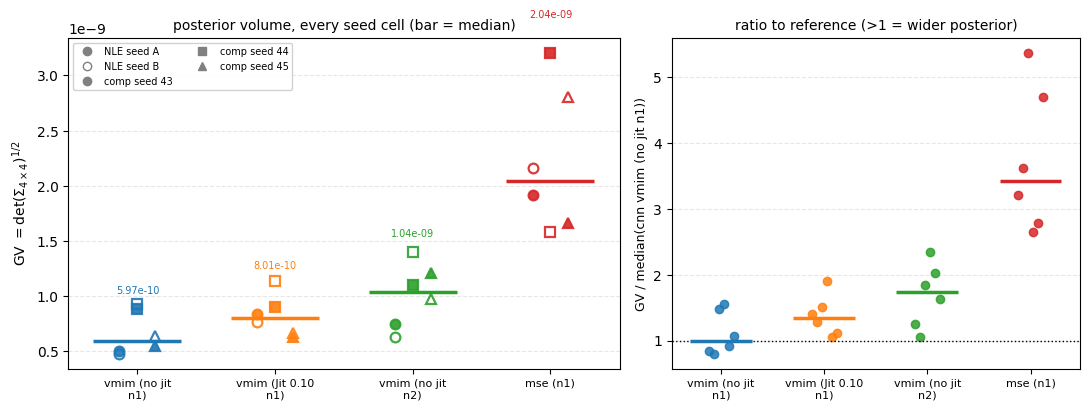

group                       n   GV median  spread(max/min)   x ref
cnn vmim (no jit n1)        6   5.967e-10             1.95    1.00
cnn vmim (Jit 0.10 n1)      6   8.007e-10             1.80    1.34
cnn vmim (no jit n2)        6   1.036e-09             2.24    1.74
cnn mse (n1)                6   2.039e-09             2.03    3.42


In [14]:
# ---- GV: one point per (compressor seed x NLE seed) ------------------------
# GV = det(Sigma_4x4)^(1/2) is a SINGLE number per run, not per parameter, so
# the arms go on x. Log y, because the arms differ by factors, not offsets.
#
# marker SHAPE = compressor seed,  FILLED/OPEN = NLE seed.
# That encoding is not decoration: for the VMIM arms the compressor seed
# dominates the scatter (sd ~0.22-0.31 in log GV vs ~0.07-0.15 for the NLE
# seed), while for MSE it is the other way round. Shape-clustering vs
# fill-pairing shows which, at a glance.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),
                         gridspec_kw=dict(width_ratios=[1.35, 1]))

ax = axes[0]
for i, g in enumerate(ORDER):
    s = DF[DF["group"] == g]
    cseeds = sorted(s["cs"].dropna().unique())
    for _, r in s.iterrows():
        j = cseeds.index(r["cs"]) if pd.notna(r["cs"]) else 0
        # deterministic horizontal offset: seeds never overplot
        dx = (j - (len(cseeds) - 1) / 2) * 0.13
        filled = (r["ns"] == sorted(s["ns"].dropna().unique())[0])
        ax.plot(i + dx, r["GV_4x4"], MK[j % len(MK)], ms=7,
                mfc=COL[g] if filled else "none", mec=COL[g], mew=1.6, alpha=.9)
    med = s["GV_4x4"].median()
    ax.hlines(med, i - .32, i + .32, color=COL[g], lw=2.5, zorder=3)
    ax.text(i, s["GV_4x4"].max() * 1.10, f"{med:.2e}", ha="center",
            fontsize=7, color=COL[g])

#ax.set_yscale("log")
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([g.replace("cnn ", "").replace(" n1", "\nn1").replace(" n2", "\nn2")
                    for g in ORDER], fontsize=8)
ax.set_ylabel(r"GV $=\det(\Sigma_{4\times4})^{1/2}$", fontsize=10)
ax.set_title("posterior volume, every seed cell (bar = median)", fontsize=10)
ax.grid(True, axis="y", ls="--", alpha=.3)

# right panel: ratio to the reference arm, so "how much better" is readable
ref = ORDER[0]
rmed = DF[DF["group"] == ref]["GV_4x4"].median()
ax = axes[1]
for i, g in enumerate(ORDER):
    v = DF[DF["group"] == g]["GV_4x4"].values / rmed
    ax.plot(np.full_like(v, i, dtype=float) + np.linspace(-.12, .12, len(v)),
            v, "o", ms=6, color=COL[g], alpha=.85)
    ax.hlines(np.median(v), i - .3, i + .3, color=COL[g], lw=2.5, zorder=3)
ax.axhline(1.0, color="k", ls=":", lw=1)
#ax.set_yscale("log")
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([g.replace("cnn ", "").replace(" n1", "\nn1").replace(" n2", "\nn2")
                    for g in ORDER], fontsize=8)
ax.set_ylabel(f"GV / median({ref})", fontsize=9)
ax.set_title("ratio to reference (>1 = wider posterior)", fontsize=10)
ax.grid(True, axis="y", ls="--", alpha=.3)

h = [plt.Line2D([], [], ls="", marker="o", mfc="grey", mec="grey", label="NLE seed A"),
     plt.Line2D([], [], ls="", marker="o", mfc="none", mec="grey", label="NLE seed B")]
h += [plt.Line2D([], [], ls="", marker=MK[j], color="grey", label=f"comp seed {c}")
      for j, c in enumerate(sorted(DF["cs"].dropna().unique()))]
axes[0].legend(handles=h, fontsize=7, ncol=2, loc="upper left", framealpha=.9)
fig.tight_layout(); plt.show()

# the numbers a caption needs: is the gap bigger than the scatter?
print(f"{'group':<26}{'n':>3}{'GV median':>12}{'spread(max/min)':>17}{'x ref':>8}")
for g in ORDER:
    v = DF[DF["group"] == g]["GV_4x4"].values
    print(f"{g:<26}{len(v):>3}{np.median(v):12.3e}{v.max()/v.min():17.2f}"
          f"{np.median(v)/rmed:8.2f}")


### 6b. Marginal widths

Left: absolute $\sigma$, log scale (the four parameters differ by an order of
magnitude). Right: ratio to the reference arm, which removes that scale
difference so the arms are directly comparable per parameter.

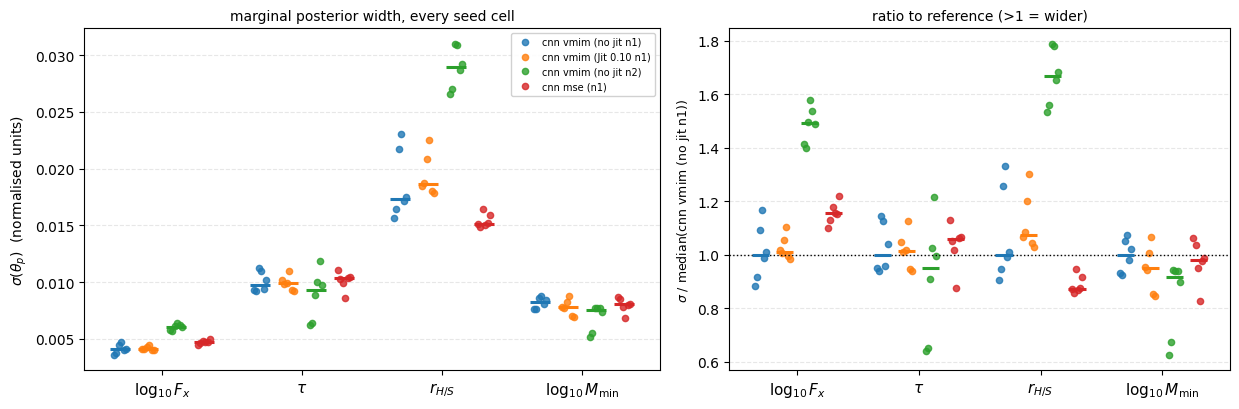

group                     $\log_{10}F_x$        $\tau$     $r_{H/S}$$\log_{10}M_{\min}$
cnn vmim (no jit n1)          4.06±  10%    9.77±   9%   17.33±  16%    8.20±   6%
cnn vmim (Jit 0.10 n1)        4.11±   4%    9.91±   7%   18.61±  10%    7.79±   9%
cnn vmim (no jit n2)          6.07±   5%    9.29±  25%   28.92±   6%    7.53±  17%
cnn mse (n1)                  4.69±   4%   10.33±   8%   15.13±   4%    8.05±   8%

(sigma x 1e3, median +- relative spread across the 6 seed cells)


In [15]:
# ---- sigma: 4 parameters on x, arms offset within each -------------------
# One point per seed cell, NOT a bar with an error bar: the whole question is
# whether the arm-to-arm gap clears the seed-to-seed scatter, and a bar hides
# exactly that. Log y because sigma spans ~4e-3 to ~3e-2 across parameters.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2),
                         gridspec_kw=dict(width_ratios=[1.15, 1]))
W = 0.8 / max(len(ORDER), 1)

ax = axes[0]
for p_i, p in enumerate(PARAMS):
    for g_i, g in enumerate(ORDER):
        v = DF[DF["group"] == g][f"sigma_{p}"].values
        x = p_i + (g_i - (len(ORDER) - 1) / 2) * W
        ax.plot(x + np.linspace(-W*.22, W*.22, len(v)), v, "o", ms=4.5,
                color=COL[g], alpha=.8,
                label=g if p_i == 0 else None)
        ax.hlines(np.median(v), x - W*.35, x + W*.35, color=COL[g], lw=2.2, zorder=3)
#ax.set_yscale("log")
ax.set_xticks(range(len(PARAMS)))
ax.set_xticklabels([PSHORT[p] for p in PARAMS], fontsize=11)
ax.set_ylabel(r"$\sigma(\theta_p)$  (normalised units)", fontsize=10)
ax.set_title("marginal posterior width, every seed cell", fontsize=10)
ax.grid(True, axis="y", ls="--", alpha=.3)
ax.legend(fontsize=7, framealpha=.9)

# right: ratio to the reference arm, per parameter -- removes the fact that
# the four parameters have wildly different natural scales
ax = axes[1]
for p_i, p in enumerate(PARAMS):
    rmed = DF[DF["group"] == ORDER[0]][f"sigma_{p}"].median()
    for g_i, g in enumerate(ORDER):
        v = DF[DF["group"] == g][f"sigma_{p}"].values / rmed
        x = p_i + (g_i - (len(ORDER) - 1) / 2) * W
        ax.plot(x + np.linspace(-W*.22, W*.22, len(v)), v, "o", ms=4.5,
                color=COL[g], alpha=.8)
        ax.hlines(np.median(v), x - W*.35, x + W*.35, color=COL[g], lw=2.2, zorder=3)
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_xticks(range(len(PARAMS)))
ax.set_xticklabels([PSHORT[p] for p in PARAMS], fontsize=11)
ax.set_ylabel(f"$\\sigma$ / median({ORDER[0]})", fontsize=9)
ax.set_title("ratio to reference (>1 = wider)", fontsize=10)
ax.grid(True, axis="y", ls="--", alpha=.3)

fig.tight_layout(); plt.show()

print(f"{'group':<26}" + "".join(f"{PSHORT[p]:>14}" for p in PARAMS))
for g in ORDER:
    s = DF[DF["group"] == g]
    cells = []
    for p in PARAMS:
        v = s[f"sigma_{p}"].values
        cells.append(f"{np.median(v)*1e3:6.2f}±{100*v.std(ddof=1)/v.mean():4.0f}%")
    print(f"{g:<26}" + "".join(f"{c:>14}" for c in cells))
print("\n(sigma x 1e3, median +- relative spread across the 6 seed cells)")


### 6c. Calibration

`calibnsig` $=(\hat\chi^2-1)/\sqrt{2/(B-1)}$ is **already in units of the
expected fluctuation**, so 0 is perfect and the shaded bands are $\pm1$ and
$\pm2$. Only positive deviations are failures: $\hat\chi^2<1$ is a rank
histogram flatter than chance, which is not a failure mode.

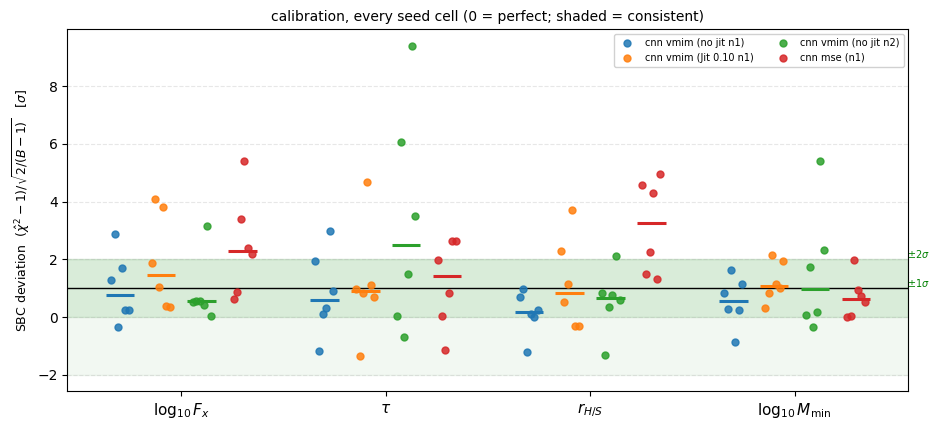

group                       RMS nsig  max nsig  per-parameter median
cnn vmim (no jit n1)            1.23      2.99  [0.76 0.6  0.18 0.56]
cnn vmim (Jit 0.10 n1)          1.99      4.68  [1.45 0.92 0.84 1.08]
cnn vmim (no jit n2)            2.87      9.40  [0.55 2.5  0.67 0.96]
cnn mse (n1)                    2.51      5.42  [2.28 1.42 3.28 0.62]

RMS over all 4 params x 6 seed cells. Lower = better calibrated.


In [17]:
# ---- calibration: nsigma from perfect, 4 parameters on x -----------------
# calibnsig = (chi2hat - 1) / sqrt(2/(nbins-1)) is ALREADY in units of the
# expected fluctuation, so 0 is perfect and the shaded bands are +-1 and +-2.
# Only positive deviations mean anything: chi2hat < 1 is a rank histogram
# FLATTER than chance, which is not a failure mode.
fig, ax = plt.subplots(figsize=(9.5, 4.4))
W = 0.8 / max(len(ORDER), 1)

ax.axhspan(0, 2, color="green", alpha=.10, zorder=0)
ax.axhspan(-2, 2, color="green", alpha=.05, zorder=0)
ax.axhline(1, color="k", lw=1, zorder=1)
ax.text(len(PARAMS) - .45, 1.05, r"$\pm1\sigma$", fontsize=7, color="green")
ax.text(len(PARAMS) - .45, 2.05, r"$\pm2\sigma$", fontsize=7, color="green")

for p_i, p in enumerate(PARAMS):
    for g_i, g in enumerate(ORDER):
        v = DF[DF["group"] == g][f"calibnsig_{p}"].values
        x = p_i + (g_i - (len(ORDER) - 1) / 2) * W
        ax.plot(x + np.linspace(-W*.22, W*.22, len(v)), v, "o", ms=5,
                color=COL[g], alpha=.85, label=g if p_i == 0 else None)
        ax.hlines(np.median(v), x - W*.35, x + W*.35, color=COL[g], lw=2.2, zorder=3)

ax.set_xticks(range(len(PARAMS)))
ax.set_xticklabels([PSHORT[p] for p in PARAMS], fontsize=11)
ax.set_ylabel(r"SBC deviation  $(\hat\chi^2-1)/\sqrt{2/(B-1)}$   [$\sigma$]", fontsize=9)
ax.set_title("calibration, every seed cell (0 = perfect; shaded = consistent)",
             fontsize=10)
ax.grid(True, axis="y", ls="--", alpha=.3)
ax.legend(fontsize=7, framealpha=.9, ncol=2)
fig.tight_layout(); plt.show()

print(f"{'group':<26}{'RMS nsig':>10}{'max nsig':>10}  per-parameter median")
for g in ORDER:
    s = DF[DF["group"] == g]
    allv = np.concatenate([s[f"calibnsig_{p}"].values for p in PARAMS])
    meds = [np.median(s[f"calibnsig_{p}"].values) for p in PARAMS]
    print(f"{g:<26}{np.sqrt((allv**2).mean()):10.2f}{allv.max():10.2f}  "
          f"{np.round(meds,2)}")
print("\nRMS over all 4 params x 6 seed cells. Lower = better calibrated.")
